In [1]:
!pip install openai numpy tensorflow matplotlib logging

In [2]:
# Cell 1: Imports & Setup
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import logging
from openai import OpenAI

# Configure logging
logging.basicConfig(filename="results.log",
                    level=logging.INFO,
                    format="%(asctime)s - %(message)s")

# Initialize OpenAI client
client = OpenAI()

In [3]:
# Cell 2: Load and preprocess CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

class_names = ["airplane","automobile","bird","cat","deer",
               "dog","frog","horse","ship","truck"]

In [4]:
# Cell 3: Build CNN model
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation="relu", input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation="relu"),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

D:\Ethans\Python\AI-Automation\myenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
# Cell 4: Train model
history = model.fit(x_train, y_train, epochs=5, batch_size=64, validation_split=0.1)

Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.4130 - loss: 1.6049 - val_accuracy: 0.5290 - val_loss: 1.3248
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.5579 - loss: 1.2447 - val_accuracy: 0.6076 - val_loss: 1.1364
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.6105 - loss: 1.1030 - val_accuracy: 0.6174 - val_loss: 1.0713
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.6459 - loss: 1.0054 - val_accuracy: 0.6398 - val_loss: 1.0504
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.6738 - loss: 0.9286 - val_accuracy: 0.6622 - val_loss: 0.9721


In [6]:
# Cell 5: Evaluate model
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"Test accuracy: {test_acc:.4f}")

313/313 - 2s - 7ms/step - accuracy: 0.6575 - loss: 0.9905
Test accuracy: 0.6575


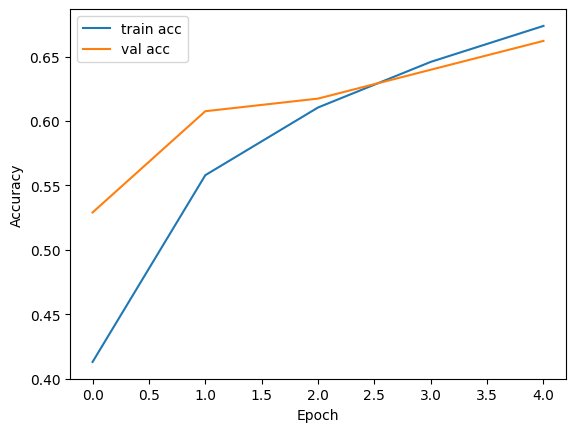

In [7]:
# Cell 6: Visualize training history
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step


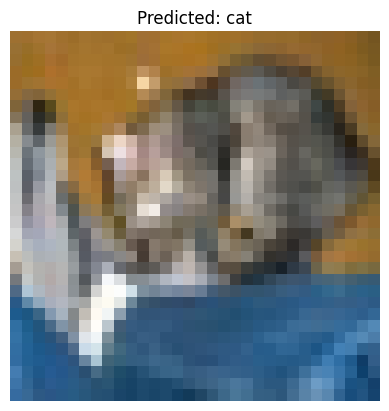

Predicted class: cat


In [8]:
# Cell 7: Predict a sample and visualize
sample_idx = 0
sample = np.expand_dims(x_test[sample_idx], axis=0)
prediction = model.predict(sample)
predicted_class = class_names[prediction.argmax()]

plt.imshow(x_test[sample_idx])
plt.title(f"Predicted: {predicted_class}")
plt.axis("off")
plt.show()

print("Predicted class:", predicted_class)

In [9]:
# Cell 8: Explain prediction with OpenAI
response = client.chat.completions.create(
    model="gpt-4.1-mini",
    messages=[
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user", "content": f"The CNN predicted '{predicted_class}' for an image. Explain why CNNs are good at image classification in simple terms."}
    ]
)

explanation = response.choices[0].message.content
print("OpenAI Explanation:", explanation)

# Log results
logging.info(f"Prediction: {predicted_class}, Explanation: {explanation}")

OpenAI Explanation: CNNs, or Convolutional Neural Networks, are good at image classification because they can automatically learn to recognize important patterns and features in pictures. Instead of looking at every pixel individually, CNNs focus on small groups of pixels to find things like edges, shapes, and textures. As the network processes the image layer by layer, it combines these simple features into more complex ones, like parts of a face or fur patterns. This helps the CNN understand what the image shows, making it effective at identifying objects such as cats.
